This walks through what `tellurix` actually does to an Arcturus spectrum, one
component at a time, on a single atlas page. The last third repeats the whole
thing for all 598 page-epochs and looks at what the ensemble says.

The forward model is one line:

$$
\mathrm{model}(\lambda) \;=\; \underbrace{e^{\sum_k c_k T_k(x)}}_{\text{continuum}}
\;\times\; \mathcal{C}_{\mathrm{ILS}}\!\left[\,
\underbrace{e^{-\sum_\ell \tau_\ell / \cos z}}_{\text{transmission}}
\;\times\;
\underbrace{S(\nu)}_{\text{star}}
\right]
$$

and everything below is one of those pieces. Two conventions to hold on to:
arrays are stored **ascending in wavenumber**, which is descending wavelength,
so pixel 0 is at the red end; and the continuum is applied **last, on pixels**,
outside the convolution.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tellurix
from tellurix import read_record

plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110, "savefig.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

ROOT = Path.cwd() if Path("pyproject.toml").exists() else Path.cwd().parent
RECORD = ROOT / "data/corrected/atlas/arcturus_atlas.h5"
record = read_record(RECORD)

PAGE, EPOCH = "ab5000_", "summer"
row = record.row(PAGE, EPOCH)
V1, V2 = float(row["v1"]), float(row["v2"])

print(f"record: {len(record.pages)} page-epochs")
print(f"demo page: {PAGE} {EPOCH}   {V1:.2f}-{V2:.2f} cm-1  "
      f"= {1e7/V2:.1f}-{1e7/V1:.1f} nm   {row['pixels']} pixels")
print(f"  median transmission {row['median_transmission']:.3f}, "
      f"residual {row['residual_rms_over_noise']:.2f} sigma, "
      f"free species {row['free_species'].decode()}")

record: 598 page-epochs
demo page: ab5000_ summer   4997.10-5027.08 cm-1  = 1989.2-2001.2 nm   1500 pixels
  median transmission 0.874, residual 3.61 sigma, free species CO2+H2O


In [2]:
def add_pixel_axis(ax, lam, npix, label="pixel index"):
    """A second x axis in pixel index.

    The arrays ascend in wavenumber, so the pixel index descends as wavelength
    ascends. Ticks are placed explicitly: matplotlib's secondary_xaxis with an
    interpolated pair of functions mislocates them badly on a nonlinear map.
    """
    top = ax.twiny()
    top.set_xlim(ax.get_xlim())
    want = np.array([w for w in (0, 300, 600, 900, 1200, npix - 1) if w < npix])
    px = np.arange(npix)
    top.set_xticks(np.interp(want, px, lam))
    top.set_xticklabels([str(int(w)) for w in want], fontsize=7.5)
    top.set_xlabel(label, fontsize=8)
    top.grid(False)
    return top

## 1. The observed spectrum

`atlas.py` is a self-contained reader for the Hinkle, Wallace & Livingston 1995
infrared atlas. A page carries three columns, and only one of them may be
fitted.

In [3]:
from tellurix import read_arcturus_page

page = read_arcturus_page(Path(record.inputs["atlas_root"]) / PAGE, EPOCH).select(V1, V2)
nu_page = page.wavenumber_vacuum_cm1
lam_page = 1e7 / nu_page

print(f"{nu_page.size} samples, {nu_page.min():.3f}-{nu_page.max():.3f} cm-1")
print(f"spacing {np.median(np.diff(nu_page)):.4f} cm-1, sha256 {page.sha256[:16]}...")

1500 samples, 4997.100-5027.080 cm-1
spacing 0.0200 cm-1, sha256 c7d342187f200e5f...


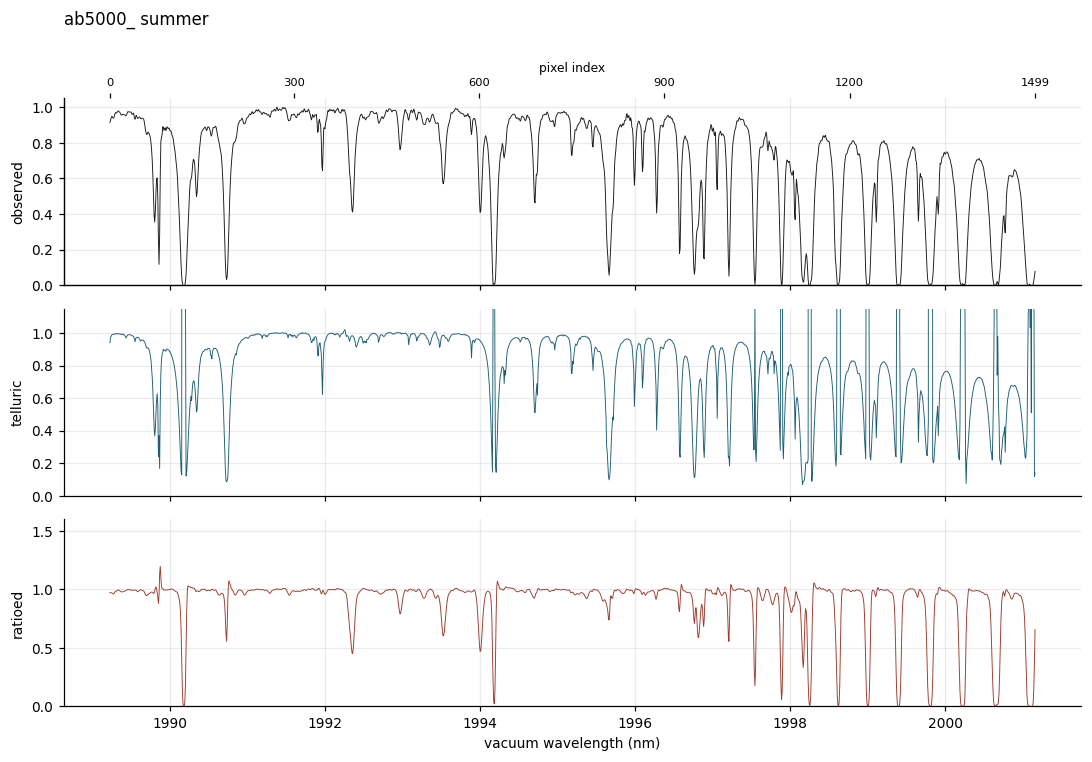

In [4]:
#| fig-cap: "The three columns of one atlas page. `observed` is the only physically complete target; `telluric` is the authors' own transmission from a different observation; `ratioed` is their division of the two, smoothed, and must never be fitted."
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
order = np.argsort(lam_page)

for ax, (name, colour) in zip(axes, [("observed", "#1c1a17"),
                                     ("telluric", "#1e5f74"),
                                     ("ratioed", "#9a3b2c")]):
    ax.plot(lam_page[order], getattr(page, name)[order], lw=0.6, color=colour)
    ax.set_ylabel(name)
axes[0].set_ylim(0, None)
axes[1].set_ylim(0, 1.15)
axes[2].set_ylim(0, 1.6)
axes[2].set_xlabel("vacuum wavelength (nm)")
add_pixel_axis(axes[0], lam_page[order], nu_page.size)
axes[0].set_title(f"{PAGE} {EPOCH}", loc="left", pad=24)
plt.tight_layout()

The `ratioed` column is the authors' `observed / telluric`, smoothed. Smoothing
destroys the band limit, and in their own words it "result[s] from mathematics
and need not convey physical information" -- so `arcturus_spectral_order`
refuses it outright. `telluric` is useful as a star-free consistency target but
it comes from a *different* observation, so agreement with it is a floor, not a
truth test.

### Pages overlap, and the overlapping copies are not identical

Adjacent atlas pages share about 5 cm$^{-1}$. The run keeps every pixel, so
those shared pixels appear in two page-epochs, fitted independently.

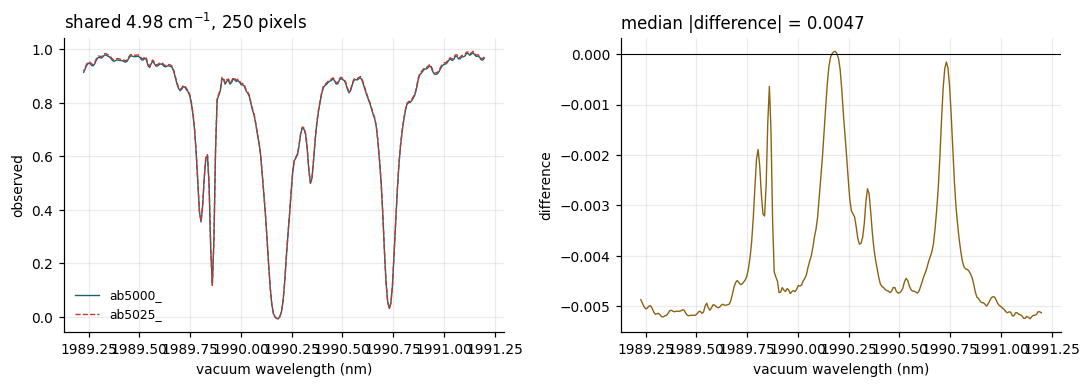

In [5]:
#| fig-cap: "The same wavenumbers in two adjacent pages. The atlas's own `observed` column differs between them, because each page carries its own scalar normalisation -- so the two copies are two reductions of one measurement, not one measurement twice."
import glob

pages_here = sorted(
    (float(r_["v1"]), r_["page"].decode()) for r_ in record.pages
    if r_["epoch"].decode() == EPOCH)
idx = [i for i, (_, p_) in enumerate(pages_here) if p_ == PAGE][0]
neighbour = pages_here[idx + 1][1]

nb_page = read_arcturus_page(Path(record.inputs["atlas_root"]) / neighbour, EPOCH)
nb_row = record.row(neighbour, EPOCH)
nb_page = nb_page.select(float(nb_row["v1"]), float(nb_row["v2"]))

lo = max(nu_page.min(), nb_page.wavenumber_vacuum_cm1.min())
hi = min(nu_page.max(), nb_page.wavenumber_vacuum_cm1.max())
wa = (nu_page >= lo) & (nu_page <= hi)
wb = (nb_page.wavenumber_vacuum_cm1 >= lo) & (nb_page.wavenumber_vacuum_cm1 <= hi)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax.plot(1e7 / nu_page[wa], page.observed[wa], lw=0.9, label=PAGE, color="#1e5f74")
ax.plot(1e7 / nb_page.wavenumber_vacuum_cm1[wb], nb_page.observed[wb], lw=0.9,
        ls="--", label=neighbour, color="#c0392b")
ax.set_xlabel("vacuum wavelength (nm)"); ax.set_ylabel("observed")
ax.legend(frameon=False, fontsize=8)
ax.set_title(f"shared {hi - lo:.2f} cm$^{{-1}}$, {int(wa.sum())} pixels", loc="left")

d = page.observed[wa] - nb_page.observed[wb]
ax2.plot(1e7 / nu_page[wa], d, lw=0.9, color="#8a6212")
ax2.axhline(0, color="k", lw=0.7)
ax2.set_xlabel("vacuum wavelength (nm)"); ax2.set_ylabel("difference")
ax2.set_title(f"median |difference| = {np.median(np.abs(d)):.4f}", loc="left")
plt.tight_layout()

## 2. The atmosphere

A layered profile, ordered top to bottom: pressure edges increase toward the
ground and altitude decreases. `AtmosphereProfile` validates that ordering in
`__post_init__`, so a profile that is upside down fails loudly rather than
producing a plausible wrong answer.

In [6]:
from tellurix import load_atmosphere_csv

profile = load_atmosphere_csv(record.inputs["profile"])
print(f"{len(profile.temperature_k)} layers, "
      f"{profile.altitude_km.max():.1f} km down to {profile.altitude_km.min():.2f} km")
print("species:", ", ".join(sorted(profile.vmr)))

12 layers, 27.1 km down to 2.25 km
species: CH4, CO, CO2, H2O, N2O, O2


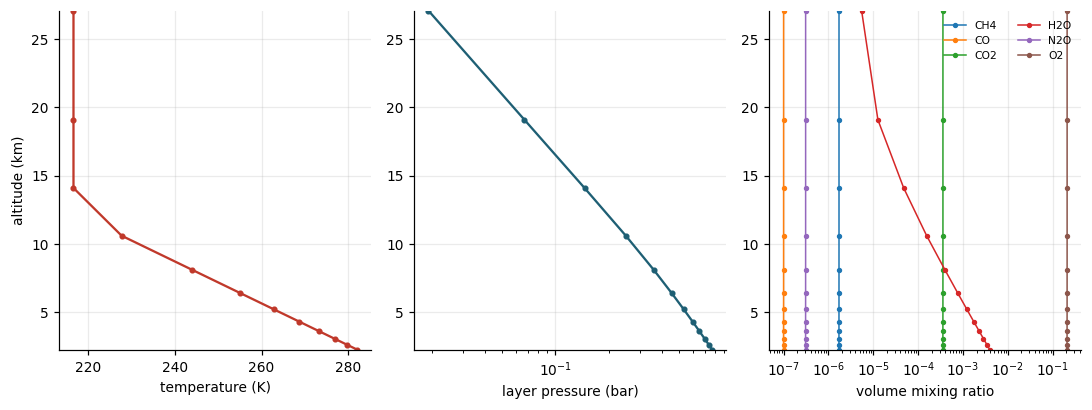

In [7]:
#| fig-cap: "The Kitt Peak profile the atlas was fitted against: temperature, pressure and the six molecular mixing ratios, all against altitude."
fig, axes = plt.subplots(1, 3, figsize=(10, 3.8))
z = profile.altitude_km

axes[0].plot(profile.temperature_k, z, "o-", ms=3, color="#c0392b")
axes[0].set_xlabel("temperature (K)"); axes[0].set_ylabel("altitude (km)")

axes[1].semilogx(profile.pressure_layer_bar, z, "o-", ms=3, color="#1e5f74")
axes[1].set_xlabel("layer pressure (bar)")

for name, values in sorted(profile.vmr.items()):
    axes[2].semilogx(np.maximum(values, 1e-12), z, "o-", ms=2.5, label=name, lw=1)
axes[2].set_xlabel("volume mixing ratio"); axes[2].legend(fontsize=7, frameon=False, ncol=2)
for ax in axes:
    ax.set_ylim(z.min(), z.max())
plt.tight_layout()

Water is the only species that falls steeply with height; the well-mixed gases
are flat. That is why a single scale factor on the water profile is a decent
proxy for precipitable water, and why the same trick is much weaker for
CO$_2$ or CH$_4$ -- scaling a flat profile is nearly degenerate with scaling the
path length.

## 3. Two margins, not one

The model needs a wavenumber grid finer than the pixels. Building it involves
*two* different paddings that are easy to conflate:

* **the line margin** (25 cm$^{-1}$) is a property of the *line list*: lines
  outside the window still contribute their wings inside it, so they must be
  selected;
* **the grid margin** (5 cm$^{-1}$) is a property of the *model*: the grid only
  has to cover the window plus what the forward model reaches back for -- the
  LSF kernel, Doppler shifts, edge padding.

Sharing one margin put 70% of every grid where there is no data.
`trim_wavenumber_grid` cuts rather than regenerates, so the samples keep both
their spacing *and* their phase.

In [8]:
from tellurix import igrins_wavenumber_grid, trim_wavenumber_grid

config = record.config
wide = igrins_wavenumber_grid(
    1e7 / V2, 1e7 / V1,
    resolving_power=float(config["resolving_power"]),
    samples_per_resolution=float(config["samples_per_resolution"]),
    margin_cm1=float(config["margin_cm1"]))
grid = trim_wavenumber_grid(wide, V1, V2, float(config["grid_margin_cm1"]))

step_kms = float(np.median(np.diff(np.log(grid))) * 299792.458)
resel_kms = 299792.458 / float(config["resolving_power"])
pixel_step_kms = float(np.median(np.diff(np.log(nu_page))) * 299792.458)

print(f"line-margin grid : {wide.size:6d} samples over {wide.min():.1f}-{wide.max():.1f} cm-1")
print(f"trimmed grid     : {grid.size:6d} samples over {grid.min():.1f}-{grid.max():.1f} cm-1"
      f"   ({wide.size / grid.size:.2f}x smaller)")
print()
print(f"model grid step  : {step_kms:.4f} km/s -> {resel_kms / step_kms:.2f} samples per resolution element")
print(f"atlas pixel step : {pixel_step_kms:.4f} km/s -> {resel_kms / pixel_step_kms:.2f} samples per resolution element")

line-margin grid :   6385 samples over 4972.1-5052.1 cm-1
trimmed grid     :   3194 samples over 4992.1-5032.1 cm-1   (2.00x smaller)

model grid step  : 0.7494 km/s -> 4.00 samples per resolution element
atlas pixel step : 1.1963 km/s -> 2.51 samples per resolution element


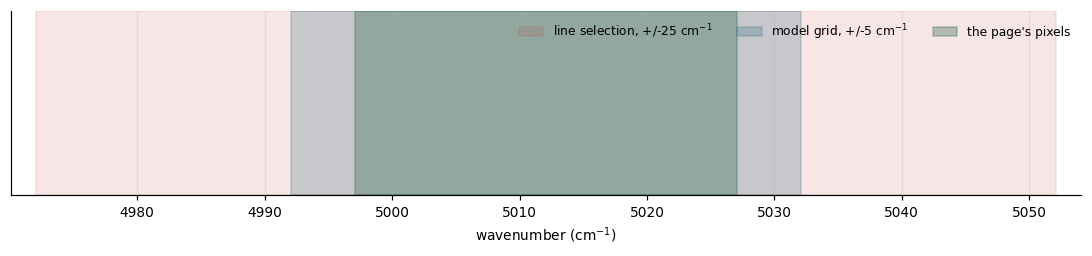

In [9]:
#| fig-cap: "What the two margins cover. The line margin selects lines whose wings reach in; the model grid only needs the window plus the forward model's own reach, so it is trimmed to a third of the width."
fig, ax = plt.subplots(figsize=(10, 2.4))
ax.axvspan(wide.min(), wide.max(), color="#c0392b", alpha=0.12,
           label=f"line selection, +/-{config['margin_cm1']:.0f} cm$^{{-1}}$")
ax.axvspan(grid.min(), grid.max(), color="#1e5f74", alpha=0.22,
           label=f"model grid, +/-{config['grid_margin_cm1']:.0f} cm$^{{-1}}$")
ax.axvspan(V1, V2, color="#2f6b4f", alpha=0.35, label="the page's pixels")
ax.set_xlim(wide.min() - 2, wide.max() + 2)
ax.set_yticks([])
ax.set_xlabel("wavenumber (cm$^{-1}$)")
ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
plt.tight_layout()

## 4. Line data

`AERLineDatabase` is a minimal HITRAN-shaped adapter over the AER 100-character
per-molecule line files. Only species with enough optical depth in this window
are fitted; the rest are carried at their profile abundance or dropped.

In [10]:
from tellurix import AERLineDatabase

MOLECULE_IDS = {"H2O": 1, "CO2": 2, "N2O": 4, "CO": 5, "CH4": 6, "O2": 7}
line_root = Path(record.inputs["aer_line_root"])

databases = {}
for name, mid in sorted(MOLECULE_IDS.items()):
    stem = f"{mid:02d}_{name}"
    try:
        databases[name] = AERLineDatabase(line_root / stem / stem, name, (V1, V2),
                                          margin_cm1=float(config["margin_cm1"]))
    except ValueError as exc:
        if not str(exc).startswith(f"no {name} lines found"):
            raise
        print(f"{name:5s}: no lines in this window")

for name, db in databases.items():
    print(f"{name:5s}: {db.nu_lines.size:6d} lines, "
          f"log S in [{db.logsij0.min():.1f}, {db.logsij0.max():.1f}]")

CO   : no lines in this window


O2   : no lines in this window
CH4  :      1 lines, log S in [-66.3, -66.3]


CO2  :   7519 lines, log S in [-69.1, -48.1]


H2O  :   2253 lines, log S in [-70.8, -50.2]


N2O  :   1622 lines, log S in [-66.8, -51.4]


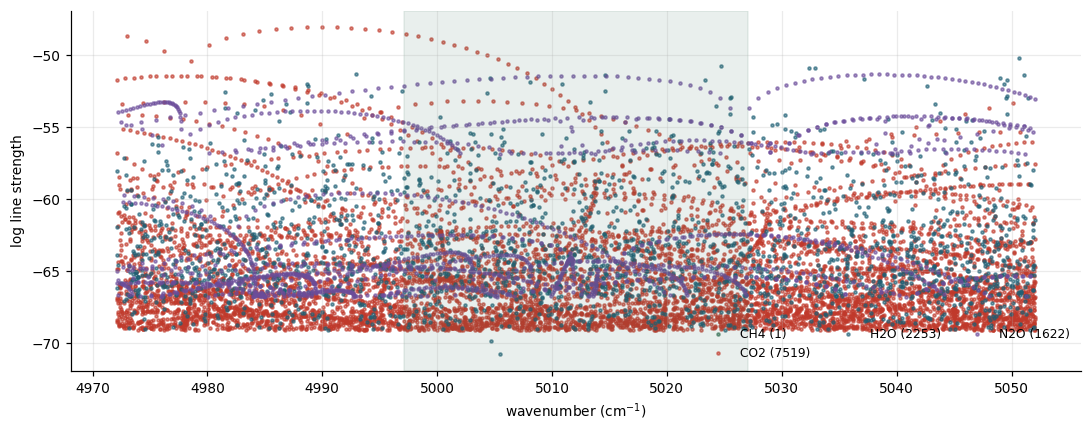

In [11]:
#| fig-cap: "Every line the model will evaluate in this window, by species and line strength. The shaded band is the page's own pixels; lines outside it are there for their wings."
fig, ax = plt.subplots(figsize=(10, 4.0))
colours = {"H2O": "#1e5f74", "CO2": "#c0392b", "CH4": "#2f6b4f",
           "CO": "#8a6212", "N2O": "#6b4c9a", "O2": "#7a736b"}
for name, db in databases.items():
    ax.scatter(db.nu_lines, db.logsij0, s=4, alpha=0.6,
               color=colours.get(name, "k"), label=f"{name} ({db.nu_lines.size})")
ax.axvspan(V1, V2, color="#2f6b4f", alpha=0.10)
ax.set_xlabel("wavenumber (cm$^{-1}$)")
ax.set_ylabel("log line strength")
ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower right")
plt.tight_layout()

## 5. Opacity and optical depth

The opacity backend wraps ExoJAX. `SparseCoreDirect` splits line/grid pairs into
a compact core list and keeps ExoJAX's exact formulas; nothing of shape
(line, grid) is ever stored, which is what took the calculators from 426 MB to
1.8 MB.

Building it is the expensive step of a page and it is done once per *window*,
not once per fit.

In [12]:
import time
from tellurix import ExoJAXOpacityBackend, MTCKDWaterContinuum

physics = record.physics
started = time.time()
opacity = ExoJAXOpacityBackend.prepare(
    databases, grid, methods=physics["opacity_method"],
    temperature_range_k=(float(np.min(profile.temperature_k)),
                         float(np.max(profile.temperature_k))),
    maximum_pressure_bar=float(np.max(profile.pressure_layer_bar)),
    vectorize_layers=bool(physics["vectorize_layers"]),
    mixed_precision=bool(physics["mixed_precision"]),
    pressure_shift=bool(physics["pressure_shift"]))
continuum_backend = MTCKDWaterContinuum.from_netcdf(record.inputs["mt_ckd"], grid)
print(f"opacity backend built in {time.time() - started:.1f} s")
print(f"species carried: {', '.join(opacity.species)}")
print(f"MT_CKD water continuum: {continuum_backend.version}")

opacity backend built in 1.2 s
species carried: CH4, CO2, H2O, N2O
MT_CKD water continuum: The MT_CKD Water Vapor Continuum - 4.3


peak vertical optical depth per species:
  CO2    119.2328   fitted
  H2O      8.4648   fitted
  N2O      0.0042   not fitted
  CH4      0.0000   not fitted


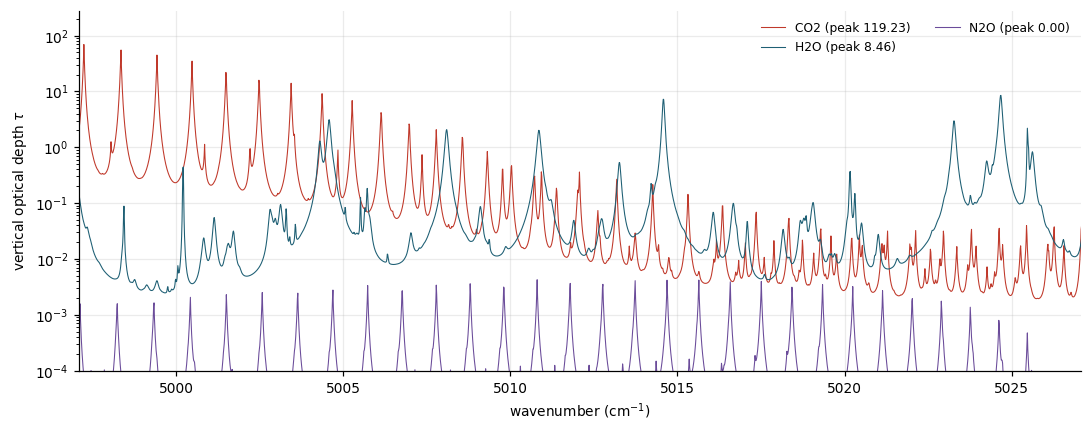

In [13]:
#| fig-cap: "Vertical optical depth per species at the profile's own abundances, summed over layers. H2O and CO2 dominate this window; the rest are present but negligible, which is what the min_optical_depth cut uses to decide what to fit."
from tellurix import TelluricModel, TelluricParameters

model = TelluricModel(profile, grid, opacity, continuum=continuum_backend,
                      accuracy_mode=physics["accuracy_mode"],
                      max_lsf_sigma_kms=float(physics["max_lsf_sigma_kms"]),
                      pixel_integration=physics["pixel_integration"])

pressure = np.asarray(profile.pressure_layer_bar)
air = np.asarray(profile.air_column_cm2)
neutral = {s: 0.0 for s in opacity.species}

fig, ax = plt.subplots(figsize=(10, 4.0))
peak = {}
for name in opacity.species:
    vmr = {s: np.asarray(profile.vmr[s]) * (1.0 if s == name else 0.0)
           for s in opacity.species}
    partial = {s: pressure * vmr[s] for s in opacity.species}
    xs = opacity.cross_sections(np.asarray(profile.temperature_k), pressure, partial)
    tau = np.sum(np.asarray(xs[name]) * (air * vmr[name])[:, None], axis=0)
    peak[name] = float(tau.max())
    if tau.max() > 1e-4:
        ax.semilogy(grid, np.maximum(tau, 1e-6), lw=0.7, label=f"{name} (peak {tau.max():.2f})",
                    color=colours.get(name, "k"))
ax.set_xlim(V1, V2)
ax.set_ylim(1e-4, None)
ax.set_xlabel("wavenumber (cm$^{-1}$)"); ax.set_ylabel(r"vertical optical depth $\tau$")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout()

print("peak vertical optical depth per species:")
for name, value in sorted(peak.items(), key=lambda kv: -kv[1]):
    fitted = "fitted" if value >= float(config["min_optical_depth"]) else "not fitted"
    print(f"  {name:5s} {value:9.4f}   {fitted}")

## 6. Transmission

$T(\nu) = \exp\left(-\sum_{\text{layers}} \tau / \cos z\right)$. The atlas is
fitted at the zenith, so $\cos z = 1$ and the fitted column scales absorb any
slant path.

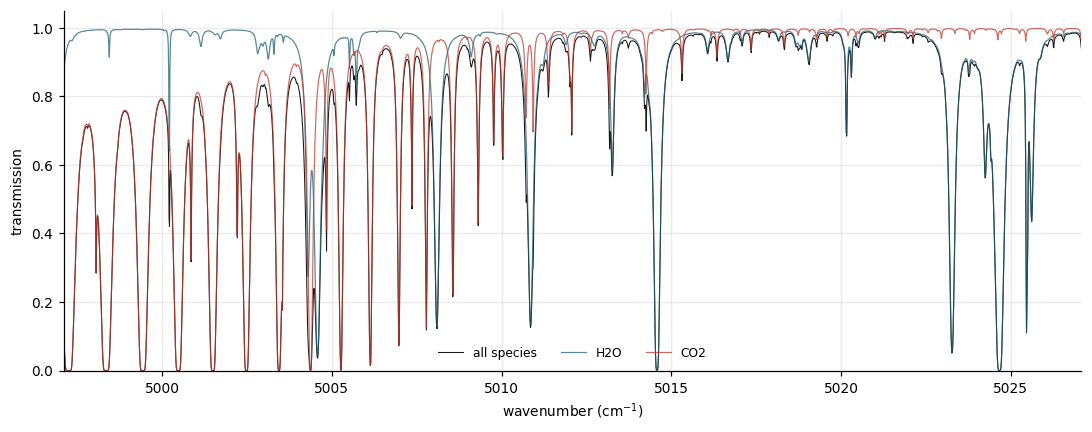

In [14]:
#| fig-cap: "The atmospheric transmission of this window, and what each species contributes on its own. Multiplying the two single-species curves reproduces the total, because optical depths add."
base = TelluricParameters(
    log_column_scales={s: 0.0 for s in opacity.species},
    velocity_kms=0.0, wavelength_stretch=0.0, lsf_sigma_kms=0.1,
    continuum_coeffs=np.zeros(4), log_jitter=0.0)

total = np.asarray(model.transmission(base, 0.0))

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(grid, total, lw=0.7, color="#1c1a17", label="all species")
for name in ("H2O", "CO2"):
    if name not in opacity.species:
        continue
    only = TelluricParameters(
        log_column_scales={s: (0.0 if s == name else -40.0) for s in opacity.species},
        velocity_kms=0.0, wavelength_stretch=0.0, lsf_sigma_kms=0.1,
        continuum_coeffs=np.zeros(4), log_jitter=0.0)
    ax.plot(grid, np.asarray(model.transmission(only, 0.0)), lw=0.8, alpha=0.75,
            color=colours[name], label=name)
ax.set_xlim(V1, V2); ax.set_ylim(0, 1.05)
ax.set_xlabel("wavenumber (cm$^{-1}$)"); ax.set_ylabel("transmission")
ax.legend(frameon=False, fontsize=8, ncol=3)
plt.tight_layout()

## 7. The stellar source

Arcturus is not a featureless lamp, so the fit needs a stellar model behind the
atmosphere. It comes from Payne Zero, synthesised in its own environment
(Payne Zero needs Python >= 3.11 while this package is pinned to 3.10 by
ExoJAX) and read back from an `npz`.

The file ships three arrays and the relationship between them matters:
`flux = flux_total / flux_continuum`, exactly. So **the spectrum is already
normalised by the model's own physical continuum** and sits at 1 where there is
no line.

In [15]:
from tellurix import StellarSpectrum, resample_stellar_continuum, prepare_stellar_source

stellar = StellarSpectrum.from_npz(record.inputs["stellar"])
print(f"{stellar.wavenumber_cm1.size} samples, "
      f"{1e7/stellar.wavenumber_cm1.max():.0f}-{1e7/stellar.wavenumber_cm1.min():.0f} nm")
print(f"flux: min {stellar.flux.min():.4f}, median {np.median(stellar.flux):.4f}, "
      f"max {stellar.flux.max():.4f}")
print(f"continuum recovered: {stellar.continuum is not None}")

1075056 samples, 900-5400 nm
flux: min 0.0927, median 0.9966, max 1.0000
continuum recovered: True


Recovering that continuum needs care. Both committed Payne Zero files store
`flux_total` and `flux_continuum` **reversed** against `wavenumber_cm1` -- the
generators reordered only `flux`. `from_npz` does not hard-code a reversal,
which would corrupt a correctly written file; it tries both orientations and
keeps whichever satisfies the identity, and returns nothing if neither does.

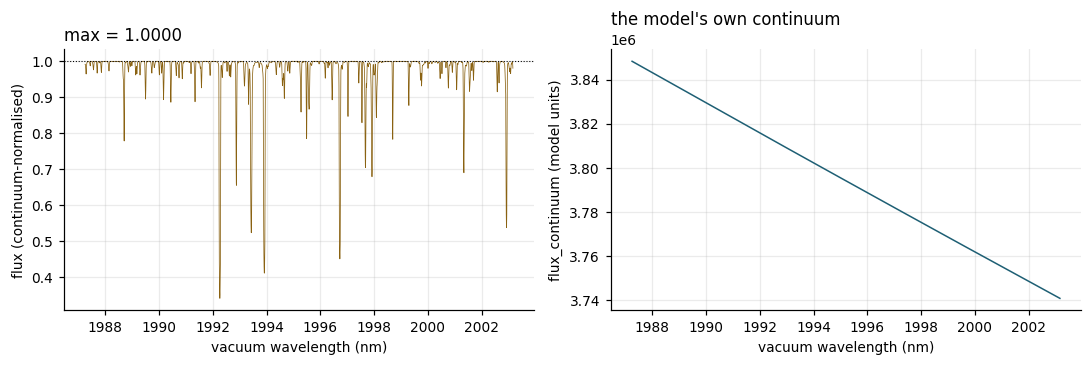

In [16]:
#| fig-cap: "The stellar model over this window. Left: the normalised spectrum, already sitting at 1 between lines. Right: the model's own physical continuum, which is smooth and carries the units."
w = (stellar.wavenumber_cm1 >= V1 - 5) & (stellar.wavenumber_cm1 <= V2 + 5)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
ax.plot(1e7 / stellar.wavenumber_cm1[w], stellar.flux[w], lw=0.5, color="#8a6212")
ax.axhline(1.0, color="k", lw=0.7, ls=":")
ax.set_xlabel("vacuum wavelength (nm)"); ax.set_ylabel("flux (continuum-normalised)")
ax.set_title(f"max = {stellar.flux[w].max():.4f}", loc="left")

ax2.plot(1e7 / stellar.wavenumber_cm1[w], stellar.continuum[w], lw=1.0, color="#1e5f74")
ax2.set_xlabel("vacuum wavelength (nm)"); ax2.set_ylabel("flux_continuum (model units)")
ax2.set_title("the model's own continuum", loc="left")
plt.tight_layout()

### Resample, broaden, normalise

`prepare_stellar_source` does three things in order: interpolate onto the model
grid, convolve with rotation and radial-tangential macroturbulence, then divide
by a scalar.

That last step is worth dwelling on. The default divides by the **median**,
which undoes the continuum normalisation the model already had and replaces it
with an arbitrary level. The scalar is exactly degenerate with the continuum's
constant term, so it changes nothing measurable -- but it is why the fitted
continuum sits a few percent below the data's envelope.

In [17]:
source = prepare_stellar_source(
    stellar, model,
    vsini_kms=float(physics["vsini_kms"]),
    limb_darkening=float(physics.get("limb_darkening", 0.6)),
    macroturbulence_kms=float(physics["macroturbulence_kms"]))

unnormalised = prepare_stellar_source(
    stellar, model,
    vsini_kms=float(physics["vsini_kms"]),
    limb_darkening=float(physics.get("limb_darkening", 0.6)),
    macroturbulence_kms=float(physics["macroturbulence_kms"]),
    normalize=False)

print(f"vsini {physics['vsini_kms']} km/s, macroturbulence {physics['macroturbulence_kms']} km/s")
print(f"as prepared (median-normalised): line-free level {source.max():.4f}")
print(f"without that division         : line-free level {unnormalised.max():.4f}")
print(f"-> the fitted continuum must sit {100 * (1 - 1 / source.max()):.2f}% below the data")

vsini 2.0 km/s, macroturbulence 2.15 km/s
as prepared (median-normalised): line-free level 1.0032
without that division         : line-free level 1.0000
-> the fitted continuum must sit 0.32% below the data


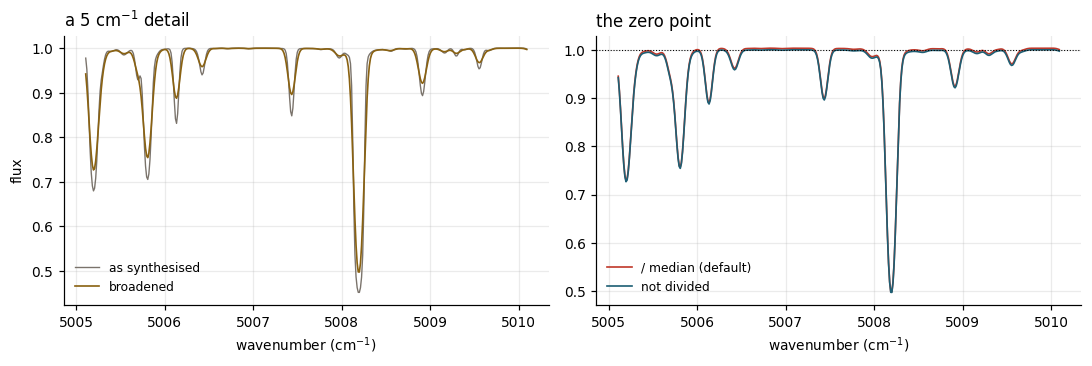

In [18]:
#| fig-cap: "Broadening and normalisation. Left: the raw model against the rotation- and macroturbulence-broadened version the fit actually uses. Right: the two normalisation choices differ by a scalar, which the continuum's constant term absorbs exactly."
from tellurix import resample_stellar_source

raw = resample_stellar_source(stellar, grid)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
sel = (grid >= V1 + 8) & (grid <= V1 + 13)
ax.plot(grid[sel], raw[sel], lw=0.9, color="#7a736b", label="as synthesised")
ax.plot(grid[sel], unnormalised[sel], lw=1.1, color="#8a6212", label="broadened")
ax.set_xlabel("wavenumber (cm$^{-1}$)"); ax.set_ylabel("flux")
ax.legend(frameon=False, fontsize=8); ax.set_title("a 5 cm$^{-1}$ detail", loc="left")

ax2.plot(grid[sel], source[sel], lw=1.1, color="#c0392b", label="/ median (default)")
ax2.plot(grid[sel], unnormalised[sel], lw=1.1, color="#1e5f74", label="not divided")
ax2.axhline(1.0, color="k", lw=0.7, ls=":")
ax2.set_xlabel("wavenumber (cm$^{-1}$)")
ax2.legend(frameon=False, fontsize=8); ax2.set_title("the zero point", loc="left")
plt.tight_layout()

## 8. The instrument

The atlas is a Fourier transform spectrometer, so the instrument profile is an
**unapodised sinc** set by the maximum optical path difference, not a Gaussian.
`BoxcarFTSInstrumentProfile` applies it by FFT -- a truncated kernel is invalid
for a sinc at any width, because the wings never stop mattering.

A fitted Gaussian sits on top of it to absorb everything the sinc does not
describe.

In [19]:
from tellurix import BoxcarFTSInstrumentProfile, ils_fingerprint

mopd = float(row["mopd_cm"])
instrument = BoxcarFTSInstrumentProfile(
    mopd_cm=mopd, wavenumber_center_cm1=float(0.5 * (V1 + V2)),
    max_residual_sigma_kms=float(physics["instrument_residual_sigma_kms"]))
model = TelluricModel(profile, grid, opacity, continuum=continuum_backend,
                      accuracy_mode=physics["accuracy_mode"],
                      max_lsf_sigma_kms=float(physics["max_lsf_sigma_kms"]),
                      pixel_integration=physics["pixel_integration"],
                      instrument=instrument)

c = 299792.458
nu_mid = 0.5 * (V1 + V2)
sinc_fwhm_cm1 = 1.20671 / (2 * mopd)
sinc_fwhm_kms = c * sinc_fwhm_cm1 / nu_mid
gauss_fwhm_kms = 2.3548 * float(row["lsf_sigma_kms"])
total_fwhm = np.hypot(sinc_fwhm_kms, gauss_fwhm_kms)

print(f"MOPD                 {mopd:.2f} cm")
print(f"sinc FWHM            {sinc_fwhm_cm1:.5f} cm-1 = {sinc_fwhm_kms:.3f} km/s  -> R = {c/sinc_fwhm_kms:,.0f}")
print(f"fitted Gaussian FWHM {gauss_fwhm_kms:.3f} km/s")
print(f"in quadrature        {total_fwhm:.3f} km/s  -> R = {c/total_fwhm:,.0f}")
print(f"the atlas documents  R = 100,000")

MOPD                 15.17 cm
sinc FWHM            0.03978 cm-1 = 2.379 km/s  -> R = 125,990
fitted Gaussian FWHM 0.264 km/s
in quadrature        2.394 km/s  -> R = 125,221
the atlas documents  R = 100,000


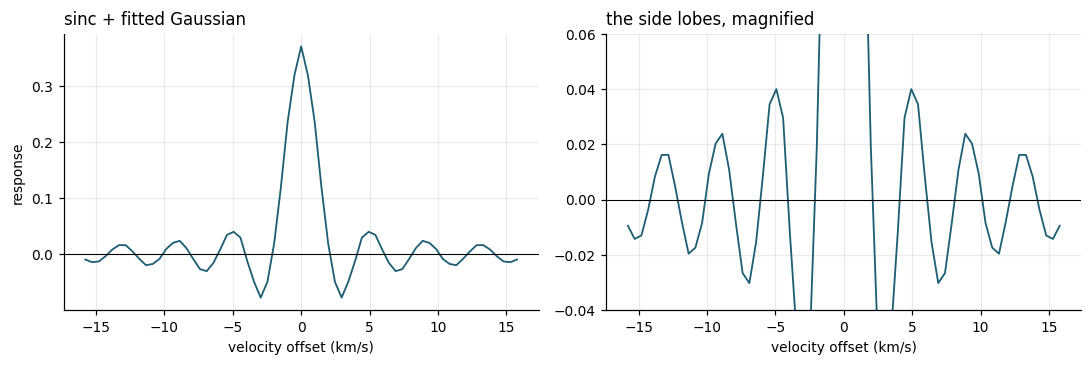

In [20]:
#| fig-cap: "The instrument profile the run actually applied, obtained by pushing a unit impulse through the real convolution rather than by re-deriving it. The sinc's negative side lobes are the signature of an unapodised FTS."
velocity, fingerprint = ils_fingerprint(instrument, float(row["lsf_sigma_kms"]),
                                        model.velocity_step_kms)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
ax.plot(velocity, fingerprint, lw=1.2, color="#1e5f74")
ax.axhline(0, color="k", lw=0.7)
ax.set_xlabel("velocity offset (km/s)"); ax.set_ylabel("response")
ax.set_title("sinc + fitted Gaussian", loc="left")

ax2.plot(velocity, fingerprint, lw=1.2, color="#1e5f74")
ax2.axhline(0, color="k", lw=0.7)
ax2.set_ylim(-0.04, 0.06)
ax2.set_xlabel("velocity offset (km/s)")
ax2.set_title("the side lobes, magnified", loc="left")
plt.tight_layout()

## 9. Putting the forward model together

Now the whole chain, in the order `predict` performs it. Note where the
continuum enters: **last, on pixels, outside the convolution**. That is why
`stellar_only / continuum` is exactly the convolved source rather than
approximately.

In [21]:
from tellurix import arcturus_spectral_order, parameters_from_row, chebyshev_continuum

order = arcturus_spectral_order(
    page, column=config["column"], source_flux_model_grid=source,
    saturation_floor=float(config["saturation_floor"]),
    telluric_ceiling=float(config["telluric_ceiling"]),
    zenith_angle_deg=float(config["zenith_angle_deg"]))

fitted = parameters_from_row(row, [s for s in sorted(MOLECULE_IDS) if s in model.species])
print("fitted parameters for this page")
for name, value in sorted(fitted.log_column_scales.items()):
    print(f"  log_column_{name:4s} {value:+.4f}  -> column x {np.exp(value):.3f}")
print(f"  velocity_kms        {float(fitted.velocity_kms):+.4f}")
print(f"  lsf_sigma_kms       {float(fitted.lsf_sigma_kms):.4f}")
print(f"  continuum_coeffs    {np.asarray(fitted.continuum_coeffs)}")

fitted parameters for this page
  log_column_CH4  +0.0000  -> column x 1.000
  log_column_CO2  +0.2079  -> column x 1.231
  log_column_H2O  +0.0954  -> column x 1.100
  log_column_N2O  +0.0000  -> column x 1.000
  velocity_kms        +0.2846
  lsf_sigma_kms       0.1122
  continuum_coeffs    [ 0.00015138  0.00701603  0.00152068 -0.00180799]


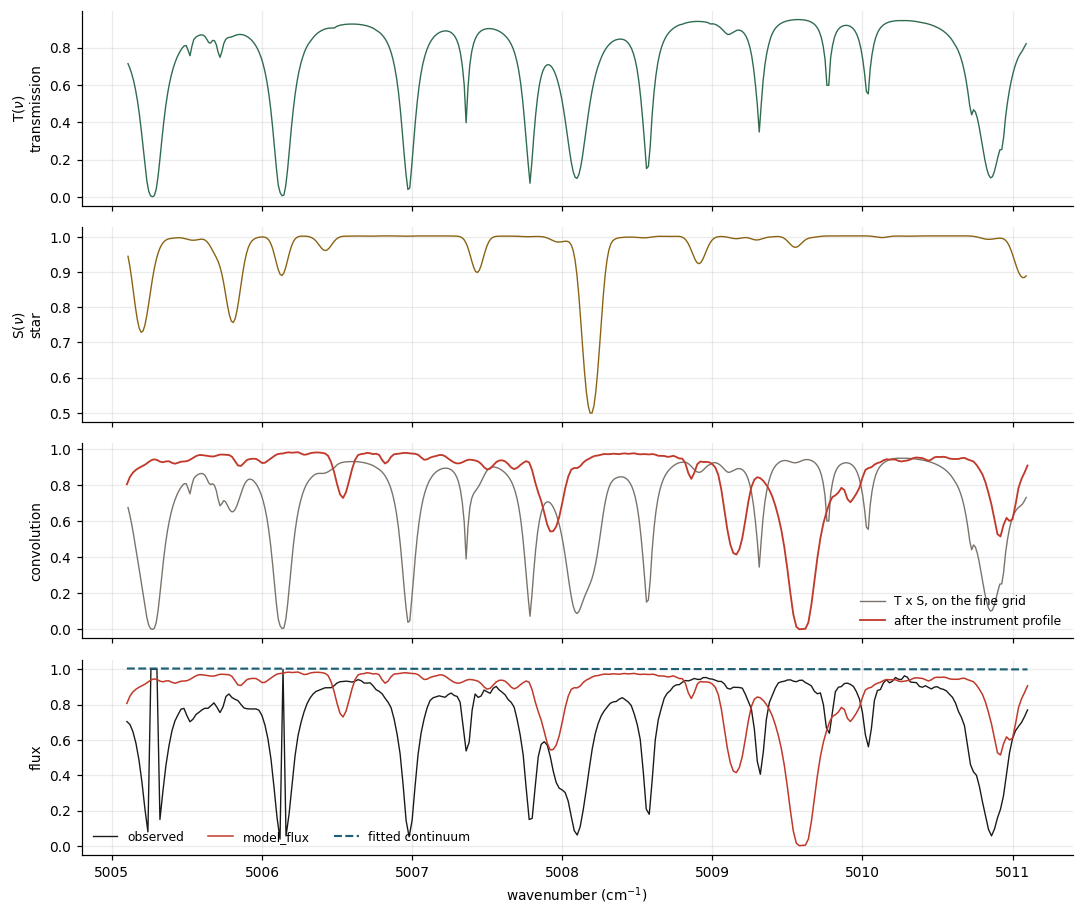

In [22]:
#| fig-cap: "The forward model, one factor at a time. Transmission and star multiply on the fine grid, the instrument profile convolves that product, and only then does the fitted Chebyshev scale it onto the data."
exact = model.precompute_opacity(fitted)
trans_hi = np.asarray(exact.transmission(fitted, order.zenith_angle_deg))
model_flux = np.asarray(exact.predict(order, fitted))

axis = np.argsort(1e7 / np.asarray(order.wavelength_vacuum_nm))
nu_pix = (1e7 / np.asarray(order.wavelength_vacuum_nm))[axis]
x_cheb = np.linspace(-1.0, 1.0, len(order.wavelength_vacuum_nm))
continuum_pix = np.asarray(chebyshev_continuum(fitted.continuum_coeffs, x_cheb))[axis]

fig, axes = plt.subplots(4, 1, figsize=(10, 8.4), sharex=True)
detail = (grid >= V1 + 8) & (grid <= V1 + 14)
dpix = (nu_pix >= V1 + 8) & (nu_pix <= V1 + 14)

axes[0].plot(grid[detail], trans_hi[detail], lw=0.9, color="#2f6b4f")
axes[0].set_ylabel("T($\\nu$)\ntransmission")

axes[1].plot(grid[detail], source[detail], lw=0.9, color="#8a6212")
axes[1].set_ylabel("S($\\nu$)\nstar")

axes[2].plot(grid[detail], (trans_hi * source)[detail], lw=0.9, color="#7a736b",
             label="T x S, on the fine grid")
axes[2].plot(nu_pix[dpix], (model_flux / np.maximum(continuum_pix, 1e-12))[dpix],
             lw=1.2, color="#c0392b", label="after the instrument profile")
axes[2].set_ylabel("convolution")
axes[2].legend(frameon=False, fontsize=8)

axes[3].plot(nu_pix[dpix], np.asarray(order.flux)[axis][dpix], lw=0.9, color="#1c1a17",
             label="observed")
axes[3].plot(nu_pix[dpix], model_flux[dpix], lw=1.0, color="#c0392b", label="model_flux")
axes[3].plot(nu_pix[dpix], continuum_pix[dpix], lw=1.4, ls="--", color="#1e5f74",
             label="fitted continuum")
axes[3].set_ylabel("flux")
axes[3].set_xlabel("wavenumber (cm$^{-1}$)")
axes[3].legend(frameon=False, fontsize=8, ncol=3)
plt.tight_layout()

## 10. Fitting

The fit is a bounded MAP optimisation over `jax.value_and_grad`, run in
**stages**: each stage frees more parameters, starting from the previous
result. The staging exists because the parameters are badly conditioned against
each other from a cold start -- the continuum and the column scales in
particular trade off almost exactly until the continuum is roughly right.

Two seams keep it cheap. `OrderObjective` compiles **once** over the full
parameter vector, and bounds and the free set stay outside the compiled
function so they may change between stages. `precompute_opacity` evaluates the
line-by-line kernel once and carries it as fixed arrays, expanded to first order
in the self-broadening partial pressure.

In [23]:
from tellurix import OrderObjective, fit_order

STAGES = {
    "continuum": ("continuum_*", "log_jitter"),
    "velocity":  ("continuum_*", "log_jitter", "velocity_kms"),
    "columns":   ("continuum_*", "log_jitter", "velocity_kms", "lsf_sigma_kms", "species_*"),
    "stellar":   ("continuum_*", "log_jitter", "velocity_kms", "lsf_sigma_kms", "species_*",
                  "stellar_velocity_kms"),
}
for name, free in STAGES.items():
    print(f"{name:10s} frees {', '.join(free)}")

continuum  frees continuum_*, log_jitter
velocity   frees continuum_*, log_jitter, velocity_kms
columns    frees continuum_*, log_jitter, velocity_kms, lsf_sigma_kms, species_*
stellar    frees continuum_*, log_jitter, velocity_kms, lsf_sigma_kms, species_*, stellar_velocity_kms


Rather than re-implement the driver's bookkeeping here, the cell below runs the
real one on this page and reads back what each stage did.

In [24]:
import json, subprocess, sys, tempfile

out = Path(tempfile.mkdtemp())
cmd = [sys.executable, str(ROOT / "scripts/fit_arcturus_page.py"),
       "--page", str(Path(record.inputs["atlas_root"]) / PAGE), "--epoch", EPOCH,
       "--v1", str(V1), "--v2", str(V2), "--species", row["free_species"].decode().replace("+", ","),
       "--stellar", str(record.inputs["stellar"]),
       "--stages", "continuum,velocity,columns,stellar",
       "--report", str(out / "fit.json"), "--diagnostic-npz", str(out / "fit.npz")]
started = time.time()
proc = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print(f"fit finished in {time.time() - started:.1f} s (returncode {proc.returncode})")
if proc.returncode != 0:
    print(proc.stderr[-2000:])
report = json.loads((out / "fit.json").read_text())
fitarr = np.load(out / "fit.npz")

fit finished in 34.2 s (returncode 0)


stage             objective  iterations  converged
continuum         -4261.338          23  True
velocity          -4412.934          38  True
columns           -4783.600          63  True
stellar           -4867.630          51  True

final residual 3.62 sigma


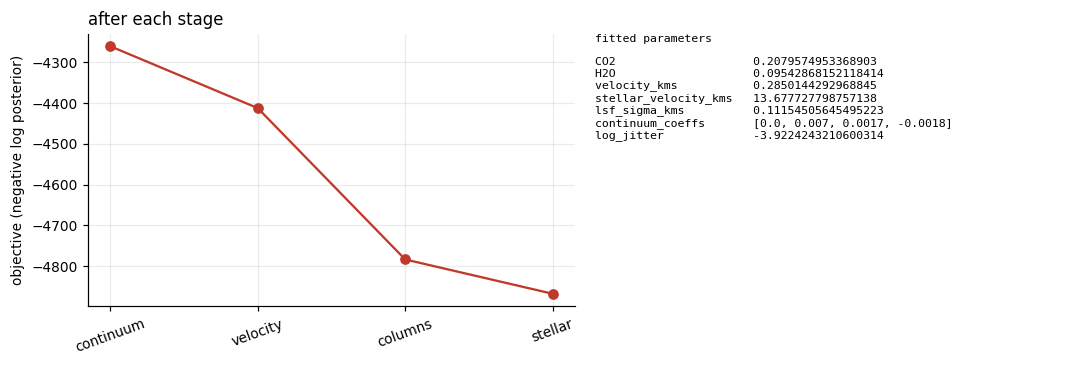

In [25]:
#| fig-cap: "What each stage buys. The continuum stage does most of the work; freeing the columns is what actually removes the telluric lines."
stages = report["stages"]
names = [s["stage"] for s in stages]
objective = np.array([float(s["objective"]) for s in stages])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
ax.plot(range(len(names)), objective, "o-", color="#c0392b")
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20)
ax.set_ylabel("objective (negative log posterior)")
if np.all(objective > 0):
    ax.set_yscale("log")
ax.set_title("after each stage", loc="left")

print(f"{'stage':12s} {'objective':>14s} {'iterations':>11s}  converged")
for s in stages:
    print(f"{s['stage']:12s} {float(s['objective']):14.3f} {s.get('iterations','?'):>11}"
          f"  {s.get('success')}")
print()
print(f"final residual {np.sqrt(report['residuals']['reduced_chi2']):.2f} sigma")

ax2.axis("off")
lines = ["fitted parameters", ""]
for k, v in report["parameters"].items():
    if k == "continuum_coeffs":
        v = np.round(np.asarray(v), 4).tolist()
    lines.append(f"{k:22s} {v}")
ax2.text(0, 1, "\n".join(lines), family="monospace", fontsize=7.5,
         va="top", transform=ax2.transAxes)
plt.tight_layout()

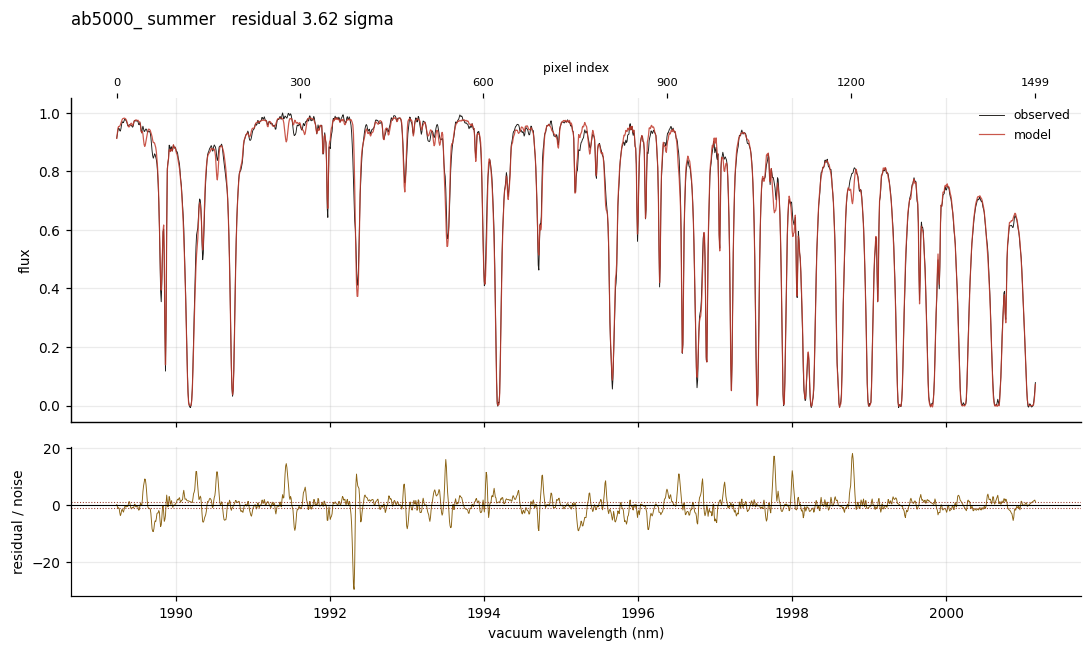

In [26]:
#| fig-cap: "The fitted page. Top: the observed spectrum and the forward model through it. Bottom: the residual, in units of the page's own noise."
obs_raw = fitarr["observed_raw"]
mf = fitarr["model_flux"]
res = fitarr["residual"]
lam_fit = fitarr["wavelength_vacuum_nm"]
mask = fitarr["mask"].astype(bool)
sigma = np.exp(report["parameters"]["log_jitter"]) if "log_jitter" in report["parameters"] else 1.0
noise = report["residuals"]["rms"] / np.sqrt(report["residuals"]["reduced_chi2"])

fig, axes = plt.subplots(2, 1, figsize=(10, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [2.6, 1.2]})
axes[0].plot(lam_fit, obs_raw, lw=0.6, color="#1c1a17", label="observed")
axes[0].plot(lam_fit, mf, lw=0.8, color="#c0392b", alpha=0.85, label="model")
axes[0].set_ylabel("flux"); axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title(f"{PAGE} {EPOCH}   residual {np.sqrt(report['residuals']['reduced_chi2']):.2f} sigma",
                  loc="left", pad=24)
add_pixel_axis(axes[0], lam_fit, lam_fit.size)

axes[1].plot(lam_fit[mask], (res / noise)[mask], lw=0.6, color="#8a6212")
axes[1].axhline(0, color="k", lw=0.7)
for s in (-1, 1):
    axes[1].axhline(s, color="#9a3b2c", lw=0.7, ls=":")
axes[1].set_ylabel("residual / noise"); axes[1].set_xlabel("vacuum wavelength (nm)")
plt.tight_layout()

## 11. The correction, and the trap in it

The corrected spectrum is

```python
corrected = (observed / model_flux) * stellar_only
```

which is algebraically `observed / T_eff` with
`T_eff = Conv[T x S] / Conv[S]`.

The obvious alternative -- divide the data by the transmission -- is **wrong**,
and not by a little. Convolution does not commute with multiplication, so
`Conv[T x S] / Conv[T]` is not `S`. Dividing by the unconvolved transmission
leaves a derivative-shaped spike beside every strong line.

peak-to-peak beside this line: naive 26.857, corrected 15112.123


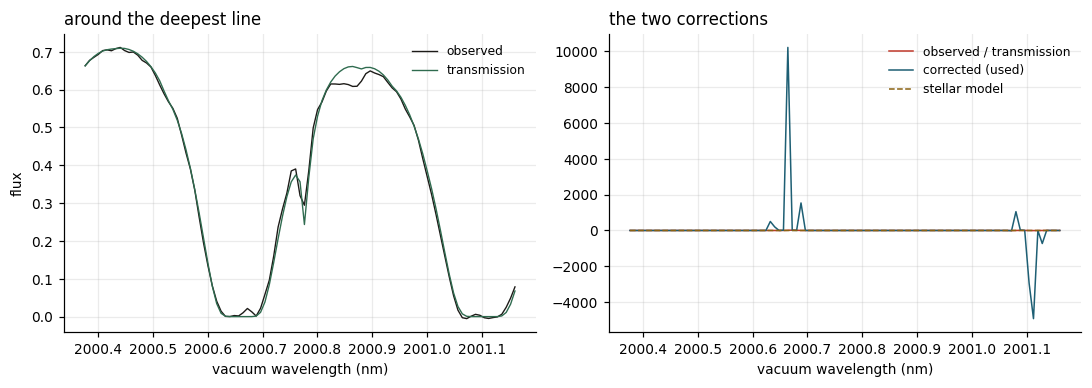

In [27]:
#| fig-cap: "Why the naive division fails. Dividing by the unconvolved transmission (red) puts a positive-then-negative excursion beside every deep line; the correction actually used (blue) does not, because it never divides by a convolved quantity."
star_only = fitarr["stellar_only_pixels"]
trans_pix = fitarr["transmission_pixels"]
corrected = (obs_raw / np.maximum(mf, 1e-6)) * star_only
naive = obs_raw / np.maximum(trans_pix, 1e-3)

deep = np.argmin(np.where(mask, trans_pix, np.inf))
lo, hi = max(deep - 90, 0), min(deep + 90, lam_fit.size)
sl = slice(lo, hi)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax.plot(lam_fit[sl], obs_raw[sl], lw=0.9, color="#1c1a17", label="observed")
ax.plot(lam_fit[sl], trans_pix[sl], lw=0.9, color="#2f6b4f", label="transmission")
ax.set_xlabel("vacuum wavelength (nm)"); ax.set_ylabel("flux")
ax.legend(frameon=False, fontsize=8); ax.set_title("around the deepest line", loc="left")

ax2.plot(lam_fit[sl], naive[sl], lw=1.0, color="#c0392b", label="observed / transmission")
ax2.plot(lam_fit[sl], corrected[sl], lw=1.0, color="#1e5f74", label="corrected (used)")
ax2.plot(lam_fit[sl], star_only[sl], lw=1.0, ls="--", color="#8a6212", label="stellar model")
ax2.set_xlabel("vacuum wavelength (nm)")
ax2.legend(frameon=False, fontsize=8); ax2.set_title("the two corrections", loc="left")
plt.tight_layout()

good = mask & (trans_pix > 0.2)
print(f"peak-to-peak beside this line: naive {np.ptp(naive[sl]):.3f}, "
      f"corrected {np.ptp(corrected[sl]):.3f}")

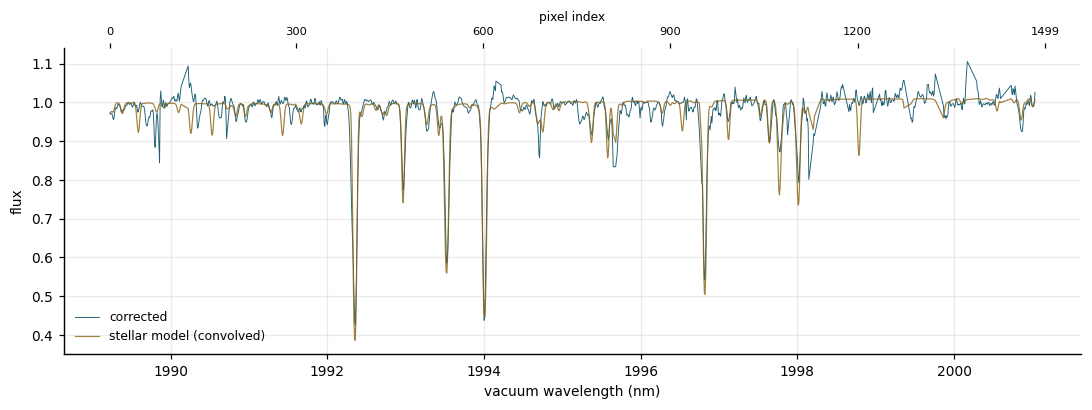

In [28]:
#| fig-cap: "The corrected page against the stellar model. What is left is Arcturus; the sky has gone."
fig, ax = plt.subplots(figsize=(10, 3.8))
show = mask & (trans_pix > 0.15)
ax.plot(lam_fit[show], corrected[show], lw=0.6, color="#1e5f74", label="corrected")
ax.plot(lam_fit[show], star_only[show], lw=0.8, color="#8a6212", alpha=0.8,
        label="stellar model (convolved)")
ax.set_xlabel("vacuum wavelength (nm)"); ax.set_ylabel("flux")
ax.legend(frameon=False, fontsize=8)
add_pixel_axis(ax, lam_fit, lam_fit.size)
plt.tight_layout()

### Which array is the correction

The `.npz` also stores `transmission`, the **unconvolved** transmission
interpolated to the pixels. It is a diagnostic. The operator the correction
applied is `model_flux / stellar_only`, and the two differ by far more than the
noise.

In [29]:
eff = mf / np.maximum(star_only, 1e-12)
d = np.abs(eff - trans_pix)[mask]
print(f"max |effective - unconvolved| = {d.max():.4f}")
print(f"page noise                    = {noise:.4f}")
print(f"-> they differ by up to {d.max()/noise:.0f}x the noise")

max |effective - unconvolved| = 0.1254
page noise                    = 0.0057
-> they differ by up to 22x the noise


## 12. All 598 page-epochs

The batch driver repeats everything above for every page of both epochs. The
product is one HDF5 **record** holding the fitted parameters and the identity of
every input -- 533 KB against 57 MB of cached arrays.

`rebuild_arcturus_page.py` reconstructs a page from the record alone and agrees
with the cache to ~1e-15. It deliberately shares no code with the fitting
driver: an independent reconstruction is evidence, calling one function twice is
not.

In [30]:
pages = record.pages
summer = pages["epoch"] == b"summer"
nu_mid_all = 0.5 * (pages["v1"] + pages["v2"])

print(f"{len(pages)} page-epochs: {summer.sum()} summer, {(~summer).sum()} winter")
print(f"coverage {pages['v1'].min():.0f}-{pages['v2'].max():.0f} cm-1 "
      f"= {1e7/pages['v2'].max():.0f}-{1e7/pages['v1'].min():.0f} nm")
print(f"{pages['pixels'].sum():,} pixels fitted, {pages['reliable'].sum():,} reliable")
print(f"converged {100 * pages['all_stages_converged'].astype(bool).mean():.1f}%")

598 page-epochs: 288 summer, 310 winter
coverage 1866-10953 cm-1 = 913-5359 nm
822,928 pixels fitted, 760,325 reliable
converged 92.3%


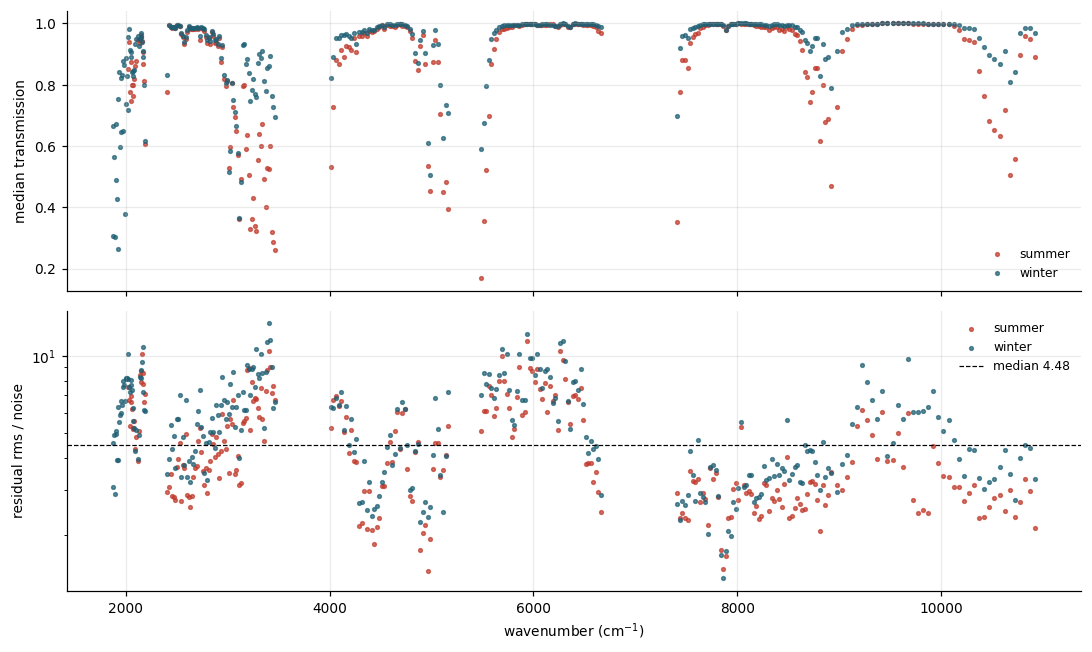

In [31]:
#| fig-cap: "Where the atlas has data and how well each page fitted. The gaps are the opaque bands between the atmospheric windows; the residual rises where the star is most blanketed, not where the sky is thickest."
fig, axes = plt.subplots(2, 1, figsize=(10, 6.0), sharex=True)
for mask_, label, colour in ((summer, "summer", "#c0392b"), (~summer, "winter", "#1e5f74")):
    axes[0].scatter(nu_mid_all[mask_], pages["median_transmission"][mask_], s=6,
                    alpha=0.7, color=colour, label=label)
    axes[1].scatter(nu_mid_all[mask_], pages["residual_rms_over_noise"][mask_], s=6,
                    alpha=0.7, color=colour, label=label)
axes[0].set_ylabel("median transmission"); axes[0].legend(frameon=False, fontsize=8)
axes[1].set_ylabel("residual rms / noise"); axes[1].set_yscale("log")
axes[1].axhline(np.median(pages["residual_rms_over_noise"]), color="k", lw=0.8, ls="--",
                label=f"median {np.median(pages['residual_rms_over_noise']):.2f}")
axes[1].legend(frameon=False, fontsize=8)
axes[1].set_xlabel("wavenumber (cm$^{-1}$)")
plt.tight_layout()

H2O  summer  n=272  median  1.239  p16-p84 1.016-2.107
H2O  winter  n=294  median  0.424  p16-p84 0.346-0.895
CO2  summer  n= 99  median  1.236  p16-p84 1.103-1.773
CO2  winter  n=120  median  1.076  p16-p84 0.879-1.567
CH4  summer  n=125  median  1.155  p16-p84 1.073-1.484
CH4  winter  n=125  median  1.052  p16-p84 0.927-1.233


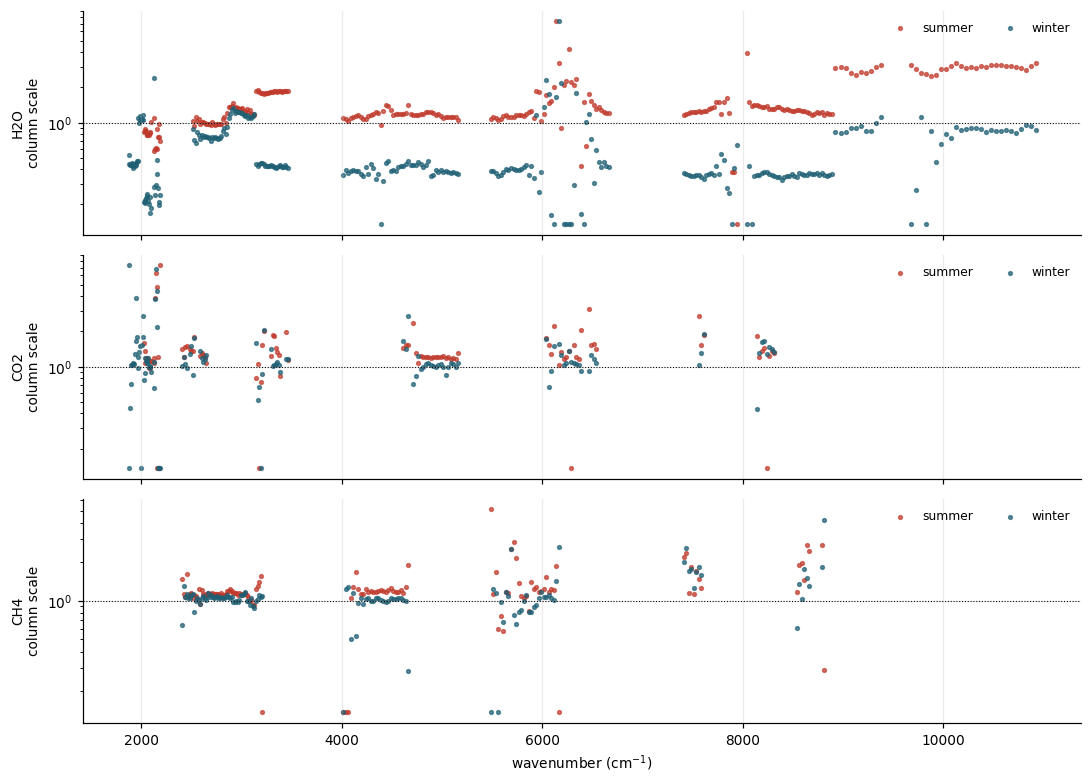

In [32]:
#| fig-cap: "The retrieved column scales across the atlas. Water varies by an order of magnitude between the two epochs, as it should; the well-mixed gases should be flat and mostly are."
fig, axes = plt.subplots(3, 1, figsize=(10, 7.2), sharex=True)
for ax, species in zip(axes, ("H2O", "CO2", "CH4")):
    col = pages[f"log_column_{species}"]
    free = np.array([species.encode() in f for f in pages["free_species"]])
    for mask_, label, colour in ((summer, "summer", "#c0392b"), (~summer, "winter", "#1e5f74")):
        k = mask_ & free
        ax.scatter(nu_mid_all[k], np.exp(col[k]), s=6, alpha=0.7, color=colour, label=label)
    ax.set_yscale("log"); ax.set_ylabel(f"{species}\ncolumn scale")
    ax.axhline(1.0, color="k", lw=0.7, ls=":")
    ax.legend(frameon=False, fontsize=8, ncol=2)
axes[-1].set_xlabel("wavenumber (cm$^{-1}$)")
plt.tight_layout()

for species in ("H2O", "CO2", "CH4"):
    free = np.array([species.encode() in f for f in pages["free_species"]])
    for mask_, label in ((summer, "summer"), (~summer, "winter")):
        k = mask_ & free
        if k.sum() < 10:
            continue
        s = np.exp(pages[f"log_column_{species}"][k])
        print(f"{species:4s} {label:7s} n={k.sum():3d}  median {np.median(s):6.3f}  "
              f"p16-p84 {np.percentile(s, 16):.3f}-{np.percentile(s, 84):.3f}")

### Where the fit runs out of room

A parameter sitting on a bound means the optimiser wanted to go further. The
dominant one by far is `lsf_sigma_kms`, and it is a symptom of the instrument
model rather than the atmosphere: the per-page MOPD *measurement* scatters about
the constant-resolving-power law the atlas actually follows, and the Gaussian
absorbs the scatter until it rails.

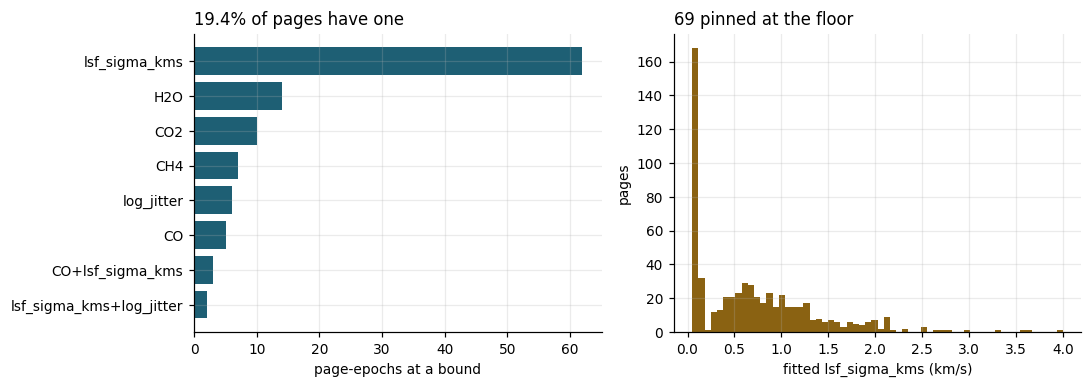

In [33]:
#| fig-cap: "Which parameters hit a bound, and the distribution of the fitted Gaussian width. The spike at the 0.05 km/s floor is the fit asking for no Gaussian at all."
import collections

counter = collections.Counter()
for s in pages["at_bound"]:
    for name in s.decode().split(","):
        if name:
            counter[name] += 1

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
items = counter.most_common(8)
ax.barh([k for k, _ in items][::-1], [v for _, v in items][::-1], color="#1e5f74")
ax.set_xlabel("page-epochs at a bound")
ax.set_title(f"{100 * np.mean([s != b'' for s in pages['at_bound']]):.1f}% of pages have one",
             loc="left")

ax2.hist(pages["lsf_sigma_kms"], bins=60, color="#8a6212")
ax2.set_xlabel("fitted lsf_sigma_kms (km/s)"); ax2.set_ylabel("pages")
ax2.set_title(f"{int((pages['lsf_sigma_kms'] < 0.0501).sum())} pinned at the floor", loc="left")
plt.tight_layout()

median R from the sinc alone        115,762
median R with the fitted Gaussian   100,110


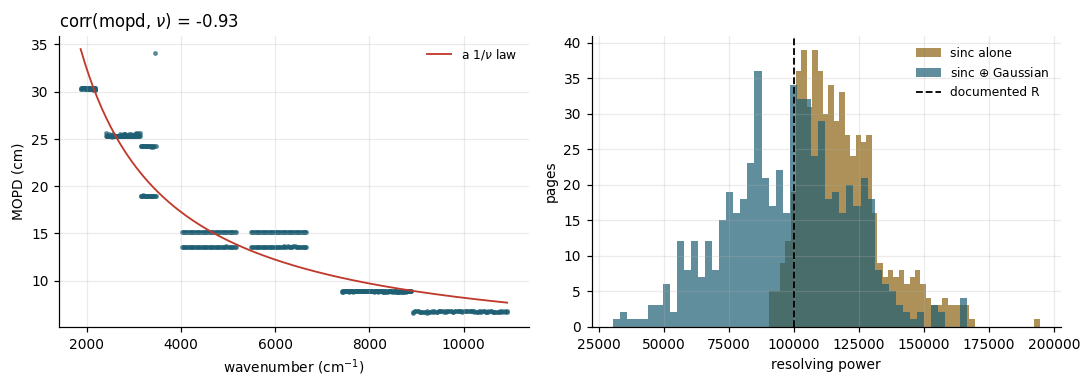

In [34]:
#| fig-cap: "The instrument profile is consistent across the atlas once it is read correctly. MOPD must track 1/nu because the compilation holds a constant resolving power; and the sinc alone reports R ~ 116,000, while the sinc and the fitted Gaussian in quadrature land on the documented 100,000."
mopd_all = pages["mopd_cm"]
sinc_kms = c * (1.20671 / (2 * mopd_all)) / nu_mid_all
gauss_kms = 2.3548 * pages["lsf_sigma_kms"]
total_kms = np.hypot(sinc_kms, gauss_kms)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax.scatter(nu_mid_all, mopd_all, s=5, alpha=0.6, color="#1e5f74")
fit_line = np.polyfit(1.0 / nu_mid_all, mopd_all, 1)
xs = np.linspace(nu_mid_all.min(), nu_mid_all.max(), 200)
ax.plot(xs, np.polyval(fit_line, 1.0 / xs), color="#c0392b", lw=1.2, label="a 1/$\\nu$ law")
ax.set_xlabel("wavenumber (cm$^{-1}$)"); ax.set_ylabel("MOPD (cm)")
ax.legend(frameon=False, fontsize=8)
ax.set_title(f"corr(mopd, $\\nu$) = {np.corrcoef(mopd_all, nu_mid_all)[0,1]:+.2f}", loc="left")

ax2.hist(c / sinc_kms, bins=50, alpha=0.7, color="#8a6212", label="sinc alone")
ax2.hist(c / total_kms, bins=50, alpha=0.7, color="#1e5f74", label="sinc $\\oplus$ Gaussian")
ax2.axvline(100_000, color="k", lw=1.2, ls="--", label="documented R")
ax2.set_xlabel("resolving power"); ax2.set_ylabel("pages")
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout()

print(f"median R from the sinc alone        {np.median(c/sinc_kms):,.0f}")
print(f"median R with the fitted Gaussian   {np.median(c/total_kms):,.0f}")

### The overlap as a consistency check

Because the run keeps every pixel, adjacent pages share about 250 pixels that
were fitted twice, independently. Two fits of identical photons must agree; where
they do not, one of them is wrong, and the parameters usually say which.

In [35]:
import os

ARRAYS = RECORD.parent
rows = []
for ep in ("summer", "winter"):
    k = np.flatnonzero(pages["epoch"] == ep.encode())
    k = k[np.argsort(pages["v1"][k])]
    for a, b in zip(k[:-1], k[1:]):
        pa = ARRAYS / f"{pages['page'][a].decode()}_{ep}.npz"
        pb = ARRAYS / f"{pages['page'][b].decode()}_{ep}.npz"
        if not (pa.exists() and pb.exists()):
            continue
        A, B = np.load(pa), np.load(pb)
        na, nb = A["wavenumber_cm1"], B["wavenumber_cm1"]
        lo_, hi_ = max(na.min(), nb.min()), min(na.max(), nb.max())
        if hi_ <= lo_:
            continue
        wa_, wb_ = (na >= lo_) & (na <= hi_), (nb >= lo_) & (nb <= hi_)
        if wa_.sum() < 30 or wa_.sum() != wb_.sum() or not np.allclose(na[wa_], nb[wb_]):
            continue
        g = A["reliable"][wa_] & B["reliable"][wb_]
        if g.sum() < 30:
            continue
        rows.append((ep,
                     float(np.sqrt(np.mean((A["corrected"][wa_][g] - B["corrected"][wb_][g])**2))),
                     float(max(pages["residual_rms_over_noise"][a],
                               pages["residual_rms_over_noise"][b])),
                     float(abs(pages["lsf_sigma_kms"][a] - pages["lsf_sigma_kms"][b]))))
print(f"{len(rows)} overlapping page pairs measured")

579 overlapping page pairs measured


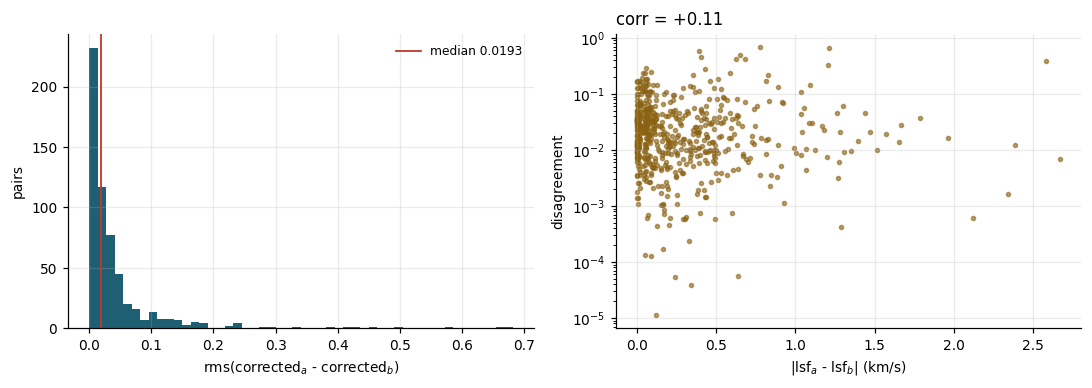

In [36]:
#| fig-cap: "Where two independent fits of the same pixels disagree, the worse of the two pages is usually the one with the bigger residual or the discrepant instrument width. The overlap turns that into a diagnostic the trimmed product did not have."
disagreement = np.array([r[1] for r in rows])
worst_resid = np.array([r[2] for r in rows])
dlsf = np.array([r[3] for r in rows])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))
ax.hist(disagreement, bins=50, color="#1e5f74")
ax.axvline(np.median(disagreement), color="#c0392b", lw=1.2,
           label=f"median {np.median(disagreement):.4f}")
ax.set_xlabel("rms(corrected$_a$ - corrected$_b$)"); ax.set_ylabel("pairs")
ax.legend(frameon=False, fontsize=8)

ax2.scatter(dlsf, disagreement, s=7, alpha=0.6, color="#8a6212")
ax2.set_xlabel("|lsf$_a$ - lsf$_b$| (km/s)"); ax2.set_ylabel("disagreement")
ax2.set_yscale("log")
ax2.set_title(f"corr = {np.corrcoef(dlsf, disagreement)[0,1]:+.2f}", loc="left")
plt.tight_layout()

## 13. What comes out

Three artefacts, and which one you want depends entirely on what you will do
with it.

| you want | take |
|---|---|
| a corrected stellar spectrum | `corrected`, or `arcturus_spectra.h5` |
| the atmosphere for your own synthesis | `arcturus_transmission.h5` |
| to reproduce or audit a fit | the record |

Two things not to do. Do not divide by `transmission` -- it is unconvolved, and
section 11 shows what that costs. And do not normalise by `continuum` if you are
measuring line strengths: it is a free polynomial fitted jointly with fixed
Payne Zero oscillator strengths, so anything divided by it is circular.
`stellar_continuum` is the model's own physical continuum and is the array to
compare against instead.

In [37]:
import h5py

spectra = ROOT / "data/corrected/arcturus_spectra.h5"
if spectra.exists():
    with h5py.File(spectra) as f:
        print(f"{spectra.name}: {f['key'].size} rows, {spectra.stat().st_size/1e6:.1f} MB")
        for name in sorted(k for k in f if not isinstance(f[k], h5py.Group)):
            d = f[name]
            if d.ndim == 2:
                print(f"  {name:26s} {d.shape}  {d.attrs.get('description','')[:60]}")
else:
    print("run scripts/export_spectra_hdf5.py to produce it")

arcturus_spectra.h5: 598 rows, 16.1 MB
  continuum                  (598, 1801)  the FITTED Chebyshev continuum: a free polynomial carrying t
  corrected                  (598, 1801)  THE PRODUCT: (observed / model_flux) * stellar_only -- the t
  effective_transmission     (598, 1801)  model_flux / stellar_only -- the operator the correction app
  model_flux                 (598, 1801)  the full forward model, convolved
  observed                   (598, 1801)  the input spectrum, NaN where not fitted
  reliable                   (598, 1801)  True where the pixel was fitted and the transmission exceeds
  sigma                      (598, 15)  
  stellar_continuum          (598, 1801)  the stellar model's own physical continuum, interpolated to 
  stellar_only               (598, 1801)  the same model with the atmosphere removed
  transmission_unconvolved   (598, 1801)  atmospheric transmission before the instrument profile; diag
  wavenumber_cm1             (598, 1801)  vacuum wavenumbe

## What this does not do

Every fit here is of Arcturus itself. Taking a fitted atmosphere to a *science
target* observed at a different airmass and time is a step that does not exist
yet -- it is the next thing to build, not something to look for.

The residual is also not a measure of telluric accuracy. It is flat against
transmission -- 0.97 in deep absorption against 1.52 at the continuum -- which
says the error is in the K1.5 III stellar line list, not in the sky.